In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

In [2]:
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [3]:
test_Box = pd.read_csv("/content/drive/MyDrive/RisultatiBoxPorzioniVeri/dimensioni_frattali.csv")
test_Rete = pd.read_csv("/content/drive/MyDrive/RisultatiRetePorzioni/dimensioni_frattali.csv")
test_No = pd.read_csv("/content/drive/MyDrive/RisultatiRetePorzioniNoAug/dimensioni_frattali.csv")

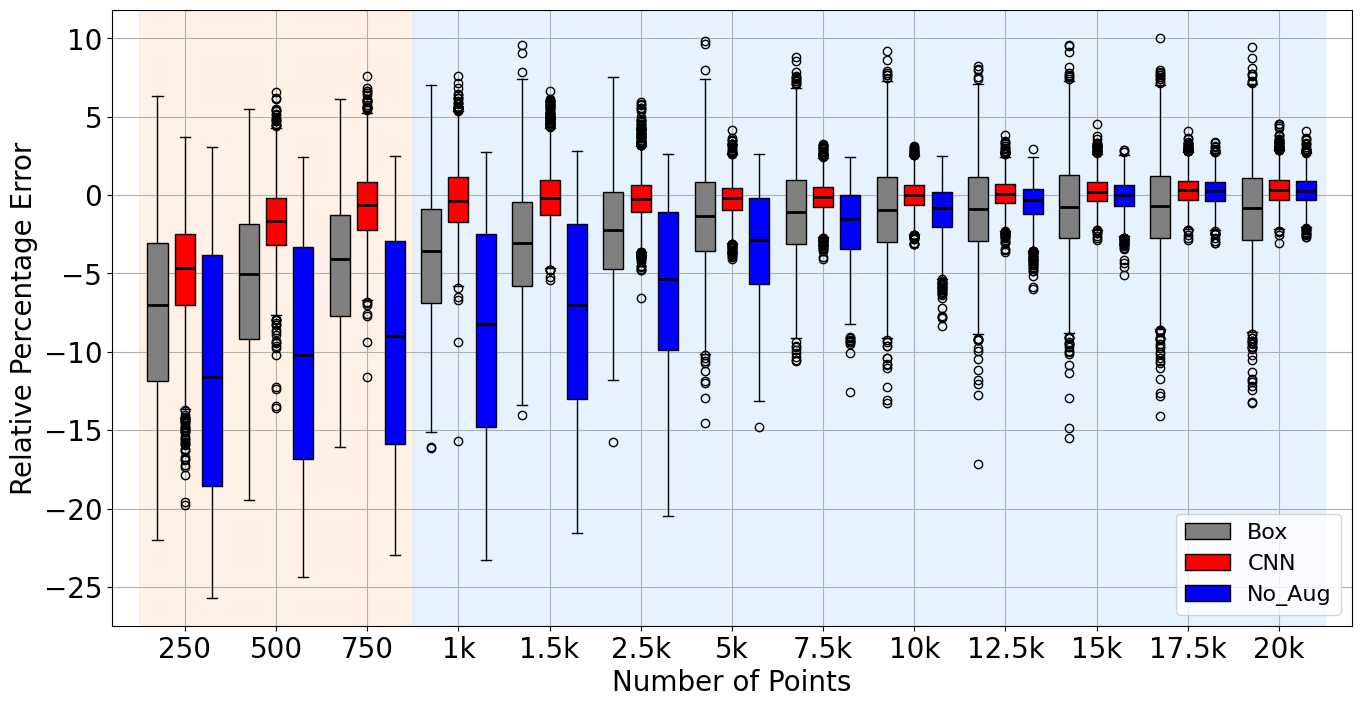

In [7]:
%matplotlib inline

porzione = ["250", "500", "750", "1k", "1.5k", "2.5k", "5k", "7.5k", "10k", "12.5k", "15k", "17.5k", "20k"]

cols = [f"Errore_{k}" for k in range(13)]

data_Box = [test_Box[col].dropna().values for col in cols]
data_Rete = [test_Rete[col].dropna().values for col in cols]
data_No = [test_No[col].dropna().values for col in cols]

soglia = 3

fig, ax = plt.subplots(figsize=(16, 8))

x = np.arange(1, 14)

offset = 0.3

bp1 = ax.boxplot(data_Box, positions=x - offset, widths=0.22,
                 patch_artist=True, boxprops=dict(facecolor="grey"), medianprops=dict(color="black", linewidth=2))
bp2 = ax.boxplot(data_Rete, positions=x, widths=0.22,
                 patch_artist=True, boxprops=dict(facecolor="red"), medianprops=dict(color="black", linewidth=2))
bp3 = ax.boxplot(data_No, positions=x + offset, widths=0.22,
                patch_artist=True, boxprops=dict(facecolor="blue"), medianprops=dict(color="black", linewidth=2))

ax.axvspan(0.5, soglia + 0.5, color="#ffe5cc", alpha=0.5)
ax.axvspan(soglia + 0.5, len(x) + 0.5, color="#d0e7ff", alpha=0.5)

ax.set_xticks(x)
ax.set_xticklabels(porzione)
ax.tick_params(axis='both', labelsize=20)


ax.set_xlabel("Number of Points", fontsize=20)
ax.set_ylabel("Relative Percentage Error", fontsize=20)
ax.grid(True)

ax.legend([bp1["boxes"][0], bp2["boxes"][0], bp3["boxes"][0]],
          ["Box", "CNN", "No_Aug"], loc="lower right", fontsize=16)

plt.show()


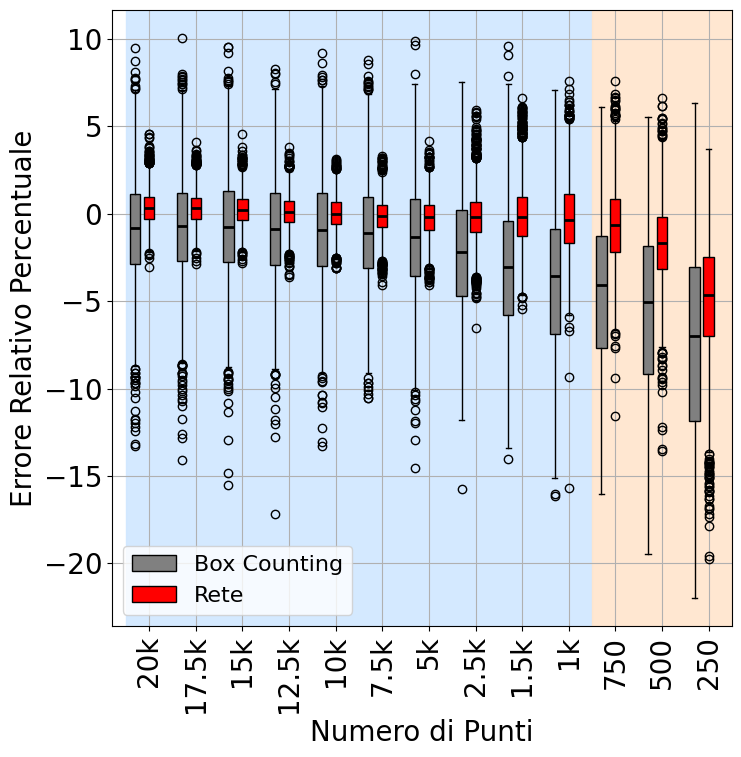

In [5]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

porzione = ["20k", "17.5k", "15k", "12.5k", "10k", "7.5k", "5k", "2.5k", "1.5k", "1k", "750", "500", "250"]

# posizioni invertite
x = np.arange(1, 14)[::-1]

# nuova soglia (invertita)
soglia_inv = 13 - soglia   # soglia = 3 → soglia_inv = 11

fig, ax = plt.subplots(figsize=(8, 8))

offset = 0.3

bp1 = ax.boxplot(data_Box, positions=x - offset, widths=0.22,
                 patch_artist=True, boxprops=dict(facecolor="grey"), medianprops=dict(color="black", linewidth=2))
bp2 = ax.boxplot(data_Rete, positions=x, widths=0.22,
                 patch_artist=True, boxprops=dict(facecolor="red"), medianprops=dict(color="black", linewidth=2))
#bp3 = ax.boxplot(data_No, positions=x + offset, widths=0.22,
 #                patch_artist=True, boxprops=dict(facecolor="blue"), medianprops=dict(color="black", linewidth=2))

# sfondo aggiornato
ax.axvspan(0.5, soglia_inv + 0.5, color="#d0e7ff", alpha=0.9)
ax.axvspan(soglia_inv + 0.5, len(x) + 0.5, color="#ffe5cc", alpha=0.9)

ax.set_xticks(x)
#ax.set_xticklabels(porzione, fontsize=20)
ax.set_xticklabels(porzione[::-1], fontsize=20, rotation = 90)
plt.yticks(fontsize=20)

#ax.tick_params(axis='both', labelsize=10)

ax.set_xlabel("Numero di Punti", fontsize=20)
ax.set_ylabel("Errore Relativo Percentuale", fontsize=20)
ax.grid(True)

ax.legend([bp1["boxes"][0], bp2["boxes"][0]], # bp3["boxes"][0]],
          ["Box Counting", "Rete"], loc="lower left", fontsize=16)

plt.show()